### Dungeons & Dragons

３つの６面体サイコロの目とその和

Sum: 3, Probability: 0.0046
Sum: 4, Probability: 0.0139
Sum: 5, Probability: 0.0278
Sum: 6, Probability: 0.0463
Sum: 7, Probability: 0.0694
Sum: 8, Probability: 0.0972
Sum: 9, Probability: 0.1157
Sum: 10, Probability: 0.1250
Sum: 11, Probability: 0.1250
Sum: 12, Probability: 0.1157
Sum: 13, Probability: 0.0972
Sum: 14, Probability: 0.0694
Sum: 15, Probability: 0.0463
Sum: 16, Probability: 0.0278
Sum: 17, Probability: 0.0139
Sum: 18, Probability: 0.0046


Text(0.5, 1.0, 'Probability distribution of 3d6')

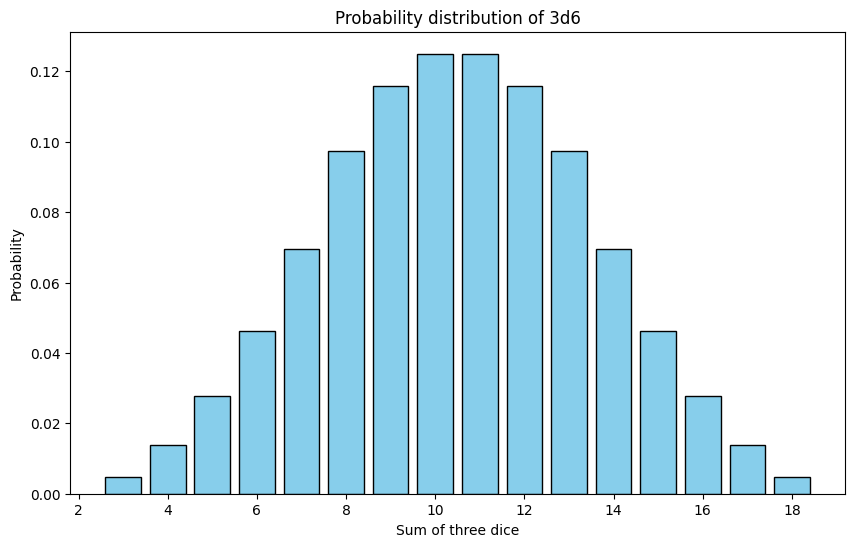

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 6面サイコロ３個を全て列挙
dice = np.arange(1,7)

# meshgridで全組み合わせを作る
d1, d2, d3 = np.meshgrid(dice, dice, dice)

sums = d1 + d2 + d3

# 3次元配列を1次元に変換
sums = sums.ravel()

# 合計値ごとの回数
values, counts = np.unique(sums, return_counts=True)

# 確率を計算
prob = counts / counts.sum()

for v, p in zip(values, prob):
    print(f"Sum: {v}, Probability: {p:.4f}")

# グラフを描画
plt.figure(figsize=(10, 6))
plt.bar(values, prob, color='skyblue', edgecolor='black')

plt.xlabel("Sum of three dice")
plt.ylabel("Probability")
plt.title("Probability distribution of 3d6")

Text(0.5, 1.0, 'Probability distribution of 3d6 (using convolution)')

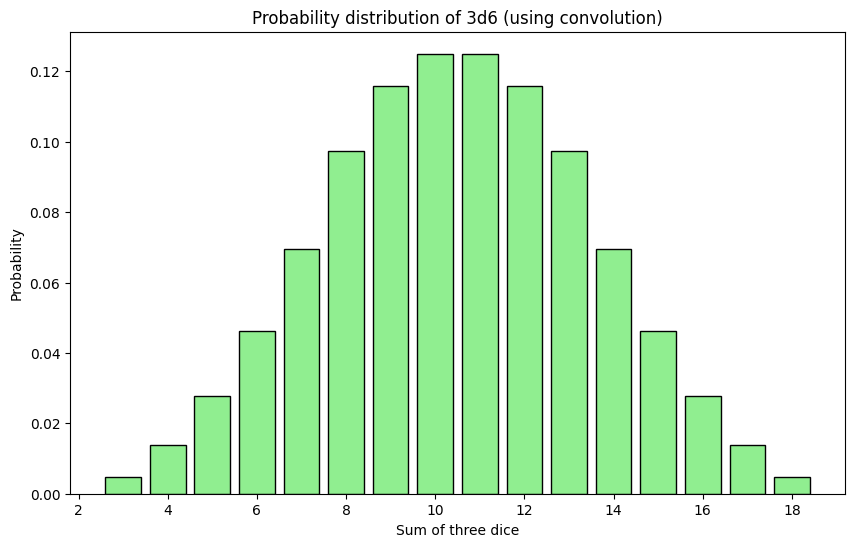

In [11]:
p = np.ones(6) / 6

p2 = np.convolve(p, p)
p3 = np.convolve(p2,p)

x = np.arange(3,19)

plt.figure(figsize=(10, 6))
plt.bar(x, p3, color='lightgreen', edgecolor='black')
plt.xlabel("Sum of three dice")
plt.ylabel("Probability")
plt.title("Probability distribution of 3d6 (using convolution)")


In [14]:
import random
import thinkbayes

class Die(thinkbayes.Pmf):
    def __init__(self, sides, name=''):
        thinkbayes.Pmf.__init__(self, name=name)
        for x in range(1,sides+1):
            self.Set(x,1)
        self.Normalize()

d6 = Die(6)
d6.Items()

dict_items([(1, 0.16666666666666666), (2, 0.16666666666666666), (3, 0.16666666666666666), (4, 0.16666666666666666), (5, 0.16666666666666666), (6, 0.16666666666666666)])

In [ ]:
dice = [d6, d6, d6]


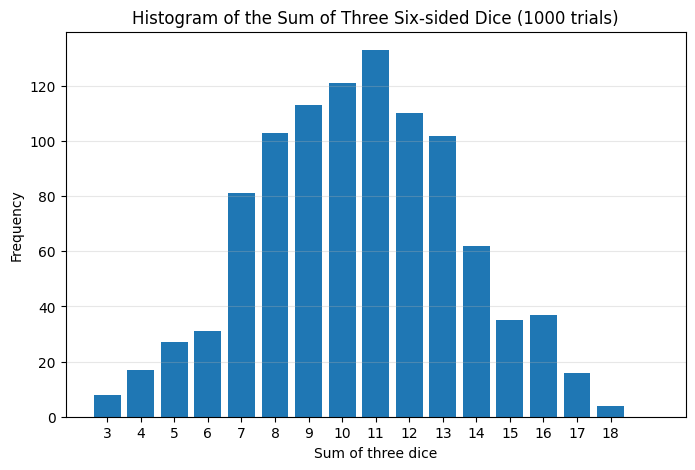

In [6]:
import random
import thinkbayes
import matplotlib.pyplot as plt

# シミュレーション回数
n = 1000

# 合計値を保存
totals = []

# 1000回サイコロを3個振る
for _ in range(n):
    total = (
        random.randint(1, 6)
        + random.randint(1, 6)
        + random.randint(1, 6)
    )
    totals.append(total)

# ヒストグラム表示
plt.figure(figsize=(8, 5))
plt.hist(
    totals,
    bins=range(3, 21),      # 3～18
    align='left',
    rwidth=0.8
)

plt.xticks(range(3, 19))
plt.xlabel("Sum of three dice")
plt.ylabel("Frequency")
plt.title("Histogram of the Sum of Three Six-sided Dice (1000 trials)")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [9]:
class Die(thinkbayes.Pmf):
    def __init__(self, sides, name=''):
        thinkbayes.Pmf.__init__(self, name=name)
        for x in range(1, sides+1):
            self.Set(x,1)
        
        self.Normalize()

In [10]:
def PmfMax(pmf1, pmf2):
    """Coputes the distribution of the max of  values drawn from two Pmfs.
    
    pmf1, pmf2: Pmf objects

    returns: new Pmf
    """

    res = thinkbayes.Pmf()
    for v1, p1 in pmf1.Items():
        for v2, p2 in pmf2.Items():
            res.Incr(max(v1, v2), p1 * p2)
        return res
    

In [11]:
pmf_dice = thinkbayes.Pmf()
pmf_dice.Set(Die(4), 5)

In [12]:
pmf_dice.Items()

dict_items([(<__main__.Die object at 0x136a71220>, 5)])

In [14]:
Die(8).Items()

dict_items([(1, 0.125), (2, 0.125), (3, 0.125), (4, 0.125), (5, 0.125), (6, 0.125), (7, 0.125), (8, 0.125)])

In [19]:
d6 = Die(6)
dice = [d6, d6, d6]

three = thinkbayes.SampleSum(dice, 1000)
three.name = "sample"
three.Items()

dict_items([(15, 0.043000000000000003), (10, 0.116), (7, 0.079), (13, 0.111), (14, 0.078), (16, 0.024), (9, 0.122), (8, 0.077), (11, 0.123), (5, 0.024), (12, 0.12), (17, 0.015), (6, 0.045), (4, 0.009000000000000001), (3, 0.007), (18, 0.007)])

In [22]:
three_exact = d6 + d6 + d6
three_exact.name = 'exact'

three_exact.Items()

dict_items([(3, 0.004629629629629629), (4, 0.013888888888888888), (5, 0.027777777777777776), (6, 0.046296296296296294), (7, 0.06944444444444445), (8, 0.09722222222222222), (9, 0.11574074074074073), (10, 0.125), (11, 0.125), (12, 0.11574074074074074), (13, 0.09722222222222224), (14, 0.06944444444444445), (15, 0.046296296296296294), (16, 0.027777777777777776), (17, 0.013888888888888888), (18, 0.004629629629629629)])

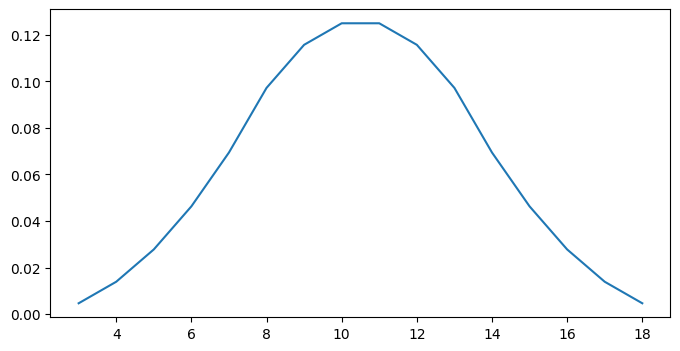

In [26]:
xs, ps = zip(*three_exact.Items())
plt.figure(figsize=(8,4))

plt.plot(xs,ps)